In [1]:
!git clone https://github.com/Shankha3/codealpha_tasks.git

Cloning into 'codealpha_tasks'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 272.63 KiB | 6.06 MiB/s, done.


In [8]:
%cd /content/codealpha_tasks

/content/codealpha_tasks


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
!find /content -name "Unemployment_Analysis.ipynb"

/content/drive/MyDrive/Colab Notebooks/Unemployment_Analysis.ipynb


In [11]:
!ls

Iris_Flower.ipynb  README.md


Dataset Shape: (72, 5)

First 5 rows:
        Date  Unemployment_Rate  Year  Month Month_Name
0 2018-01-01                4.1  2018      1        Jan
1 2018-02-01                4.1  2018      2        Feb
2 2018-03-01                4.0  2018      3        Mar
3 2018-04-01                3.9  2018      4        Apr
4 2018-05-01                3.8  2018      5        May

Basic Statistics:
count    72.000000
mean      4.719444
std       2.208284
min       3.400000
25%       3.600000
50%       3.800000
75%       4.650000
max      14.700000
Name: Unemployment_Rate, dtype: float64

Missing Values: 0

Unemployment Rate by Year (Mean):
Year
2018    3.89
2019    3.67
2020    8.11
2021    5.37
2022    3.65
2023    3.63
Name: Unemployment_Rate, dtype: float64


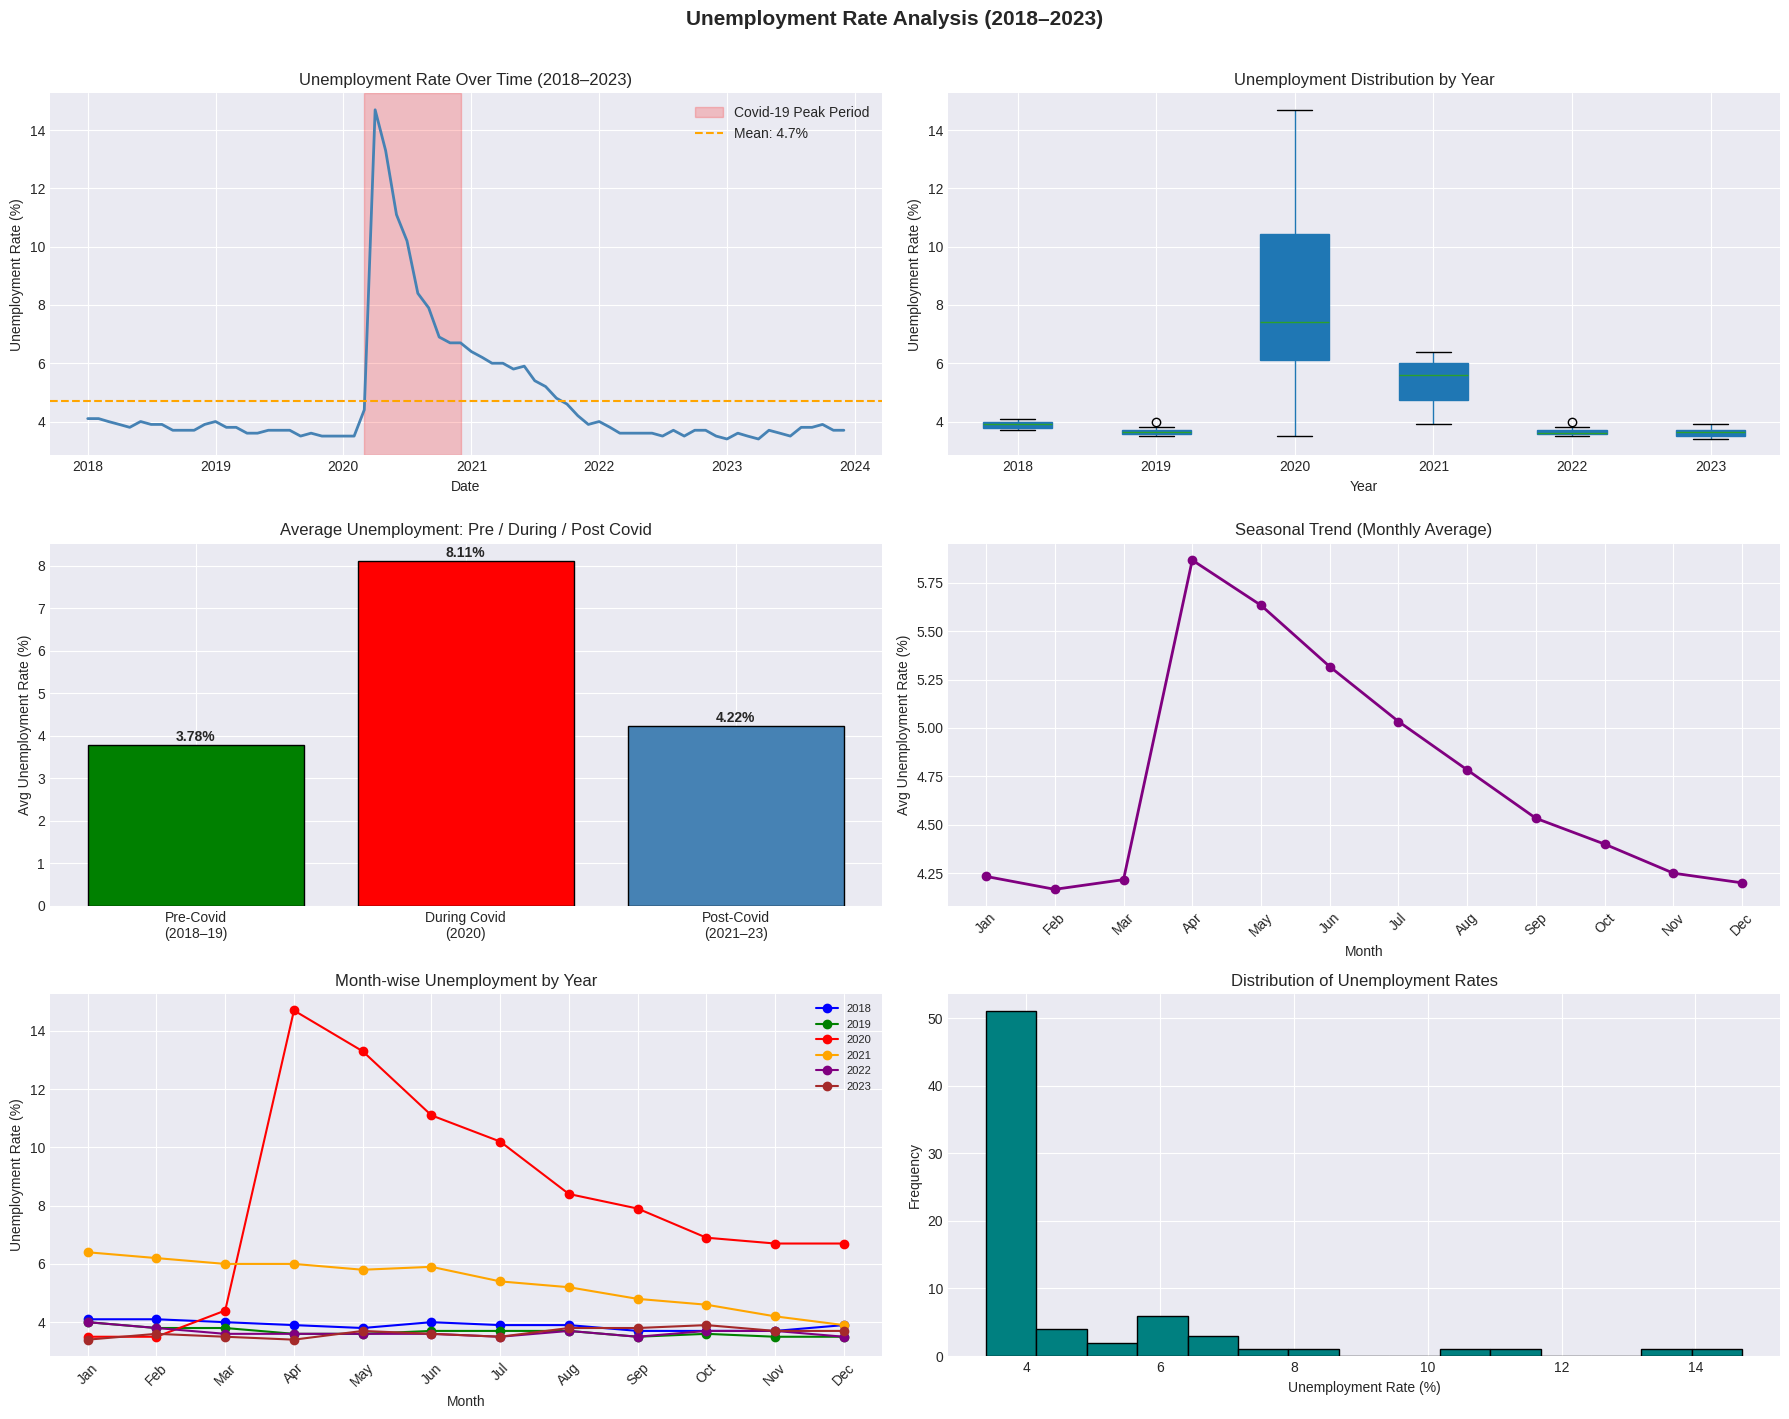


         KEY INSIGHTS

📌 Overall Mean Unemployment Rate : 4.72%
📌 Peak Unemployment              : 14.7% (April 2020)
📌 Lowest Unemployment            : 3.4% (January 2023)

📌 Pre-Covid Avg  (2018–19)       : 3.78%
📌 During Covid Avg (2020)        : 8.11%
📌 Post-Covid Avg (2021–23)       : 4.22%

⚠️  Covid-19 caused unemployment to jump by +10.9% at its peak

📌 Highest avg month : Apr
📌 Lowest avg month  : Feb

📌 Month vs Rate Correlation: -0.043 (p=0.719)

✅ Analysis Complete!


In [ ]:
# Task 2: Unemployment Analysis with Python
# Analyzing unemployment trends including Covid-19 impact

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ─────────────────────────────────────────
# 1. CREATE / LOAD DATASET
# ─────────────────────────────────────────
# US Monthly Unemployment Rate (%) — 2018 to 2023
# Source: Bureau of Labor Statistics (realistic values)

data = {
    'Date': pd.date_range(start='2018-01', periods=72, freq='MS'),
    'Unemployment_Rate': [
        # 2018
        4.1, 4.1, 4.0, 3.9, 3.8, 4.0, 3.9, 3.9, 3.7, 3.7, 3.7, 3.9,
        # 2019
        4.0, 3.8, 3.8, 3.6, 3.6, 3.7, 3.7, 3.7, 3.5, 3.6, 3.5, 3.5,
        # 2020 — COVID spike
        3.5, 3.5, 4.4, 14.7, 13.3, 11.1, 10.2, 8.4, 7.9, 6.9, 6.7, 6.7,
        # 2021 — Recovery
        6.4, 6.2, 6.0, 6.0, 5.8, 5.9, 5.4, 5.2, 4.8, 4.6, 4.2, 3.9,
        # 2022
        4.0, 3.8, 3.6, 3.6, 3.6, 3.6, 3.5, 3.7, 3.5, 3.7, 3.7, 3.5,
        # 2023
        3.4, 3.6, 3.5, 3.4, 3.7, 3.6, 3.5, 3.8, 3.8, 3.9, 3.7, 3.7,
    ]
}

df = pd.DataFrame(data)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic Statistics:")
print(df['Unemployment_Rate'].describe())

# ─────────────────────────────────────────
# 2. DATA CLEANING & EXPLORATION
# ─────────────────────────────────────────
print("\nMissing Values:", df.isnull().sum().sum())
print("\nUnemployment Rate by Year (Mean):")
print(df.groupby('Year')['Unemployment_Rate'].mean().round(2))

# ─────────────────────────────────────────
# 3. VISUALIZATIONS
# ─────────────────────────────────────────

plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(18, 14))

# --- Plot 1: Full Timeline ---
ax1 = fig.add_subplot(3, 2, 1)
ax1.plot(df['Date'], df['Unemployment_Rate'],
         color='steelblue', linewidth=2)
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'),
            alpha=0.2, color='red', label='Covid-19 Peak Period')
ax1.axhline(y=df['Unemployment_Rate'].mean(), color='orange',
            linestyle='--', label=f"Mean: {df['Unemployment_Rate'].mean():.1f}%")
ax1.set_title('Unemployment Rate Over Time (2018–2023)', fontsize=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Unemployment Rate (%)')
ax1.legend()

# --- Plot 2: Year-wise Boxplot ---
ax2 = fig.add_subplot(3, 2, 2)
df.boxplot(column='Unemployment_Rate', by='Year', ax=ax2,
           patch_artist=True)
ax2.set_title('Unemployment Distribution by Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Unemployment Rate (%)')
plt.sca(ax2)
plt.title('Unemployment Distribution by Year')

# --- Plot 3: Covid Impact Comparison ---
ax3 = fig.add_subplot(3, 2, 3)
pre_covid  = df[df['Year'] < 2020]['Unemployment_Rate']
covid      = df[df['Year'] == 2020]['Unemployment_Rate']
post_covid = df[df['Year'] > 2020]['Unemployment_Rate']

ax3.bar(['Pre-Covid\n(2018–19)', 'During Covid\n(2020)',
         'Post-Covid\n(2021–23)'],
        [pre_covid.mean(), covid.mean(), post_covid.mean()],
        color=['green', 'red', 'steelblue'], edgecolor='black')
ax3.set_title('Average Unemployment: Pre / During / Post Covid')
ax3.set_ylabel('Avg Unemployment Rate (%)')
for i, v in enumerate([pre_covid.mean(), covid.mean(), post_covid.mean()]):
    ax3.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# --- Plot 4: Monthly Seasonal Trend ---
ax4 = fig.add_subplot(3, 2, 4)
monthly_avg = df.groupby('Month')['Unemployment_Rate'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
ax4.plot(months, monthly_avg.values, marker='o',
         color='purple', linewidth=2)
ax4.set_title('Seasonal Trend (Monthly Average)')
ax4.set_xlabel('Month')
ax4.set_ylabel('Avg Unemployment Rate (%)')
ax4.tick_params(axis='x', rotation=45)

# --- Plot 5: Year-wise Line Comparison ---
ax5 = fig.add_subplot(3, 2, 5)
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
for i, year in enumerate(df['Year'].unique()):
    yearly = df[df['Year'] == year]
    ax5.plot(range(1, 13), yearly['Unemployment_Rate'].values,
             marker='o', label=str(year), color=colors[i])
ax5.set_title('Month-wise Unemployment by Year')
ax5.set_xlabel('Month')
ax5.set_ylabel('Unemployment Rate (%)')
ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(months, rotation=45)
ax5.legend(fontsize=8)

# --- Plot 6: Histogram ---
ax6 = fig.add_subplot(3, 2, 6)
ax6.hist(df['Unemployment_Rate'], bins=15,
         color='teal', edgecolor='black')
ax6.set_title('Distribution of Unemployment Rates')
ax6.set_xlabel('Unemployment Rate (%)')
ax6.set_ylabel('Frequency')

plt.suptitle('Unemployment Rate Analysis (2018–2023)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('unemployment_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# ─────────────────────────────────────────
# 4. KEY INSIGHTS
# ─────────────────────────────────────────
print("\n" + "="*50)
print("         KEY INSIGHTS")
print("="*50)

peak = df.loc[df['Unemployment_Rate'].idxmax()]
low  = df.loc[df['Unemployment_Rate'].idxmin()]

print(f"\n📌 Overall Mean Unemployment Rate : {df['Unemployment_Rate'].mean():.2f}%")
print(f"📌 Peak Unemployment              : {peak['Unemployment_Rate']}% ({peak['Date'].strftime('%B %Y')})")
print(f"📌 Lowest Unemployment            : {low['Unemployment_Rate']}% ({low['Date'].strftime('%B %Y')})")
print(f"\n📌 Pre-Covid Avg  (2018–19)       : {pre_covid.mean():.2f}%")
print(f"📌 During Covid Avg (2020)        : {covid.mean():.2f}%")
print(f"📌 Post-Covid Avg (2021–23)       : {post_covid.mean():.2f}%")

covid_jump = covid.max() - pre_covid.mean()
print(f"\n⚠️  Covid-19 caused unemployment to jump by +{covid_jump:.1f}% at its peak")

# Seasonal pattern
print(f"\n📌 Highest avg month : {months[monthly_avg.idxmax()-1]}")
print(f"📌 Lowest avg month  : {months[monthly_avg.idxmin()-1]}")

# Correlation: Month vs Rate (seasonal check)
corr, pval = stats.pearsonr(df['Month'], df['Unemployment_Rate'])
print(f"\n📌 Month vs Rate Correlation: {corr:.3f} (p={pval:.3f})")
print("\n✅ Analysis Complete!")